What is micrograd?
Micrograd is basically an autograd engine. It's a scalar-valued autograd engine.

Autograd is short for automatic gradient. And really what it does is it implements backpropagation.

Backpropagation is this algorithm that allows you to efficiently evaluate the gradient of some kind of a loss function with respect to the weights of neural network. And what that allows us to do then is we can iteratively tune the weights of that neural network to minimize the loss function and therefore improve the accuracy of the network.

So backpropagation would be at the mathematical core of and modern deep neural network library, like Pytorch or JAX.

Neuarl networks are just a mathematical expression they take the input data as an input and they take the weights of a neural network as an input and it's a mathematical expression and your output is predictions of your neural net or the loss function.

## micrograd

In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

Let's define a function, a scalar-valid function.

It just takes a single scalar x and returns a single scalar y.

In [2]:
def f(x):
    return 3*x**2 - 4*x + 5

In [3]:
f(3.0)

20.0

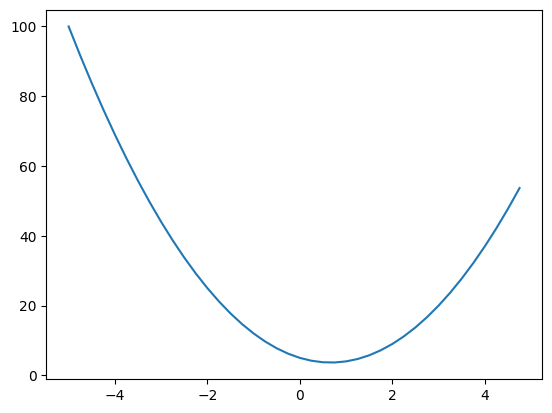

In [4]:
xs = np.arange(-5, 5, 0.25)
xs
ys = f(xs)
ys
plt.plot(xs, ys)

So now I'd like to think through what is the derivative of this function at any single input point x?

What is the derivative at different points x of this function?

No one in neural networks actually writes out the expression for the neural network net. It would be a massive expression. And so we're not going to take this kind of symbolic approach.

Instead, What I'd like to look at the definition of derivative and just make sure that we really understand what derivative is measuring, what it's telling you about the function.

The definiton of derivative is the limit as 'h' goes to zero of 'f of x+h' minus 'f of x' over h.
So basically what it's saying is if you slightly bump up at some point x by a small number h, how does the function respond? With what sensitivity does it respond? What is the slope at that point? Does the function go up or go down? And by how much? And that's the slope of that function, the slope of that response at that point.

And so we basically evaluate the derivative here numerically by taking a very small h. And the definition would ask us to take h to zero.

In [5]:
h = 0.001
x = 3.0
f(x + h)

20.014003000000002

Do you expect 'f of x+h' to be slightly greater 20? or do you expect to be slightly lower than 20. 
If we slightly go positively, the function will respond positively. So you'd expect this to be slightly greater than 20.

And by how much is telling you the sort of the strength of that slope. The size of the slope.

In [6]:
h = 0.001
x = 3.0
(f(x + h) - f(x))/h

14.00300000000243

So this is just a numerical approximation of the slope, because we have to make age very small to converge to the exact amount.

In [7]:
h = 0.001
x = -3.0
(f(x + h) - f(x))/h

-21.996999999998934

In [8]:
h = 0.001
x = 2/3
(f(x + h) - f(x))/h

0.0029999999995311555

Let's get more complex case.

In [9]:
a = 2.0
b = -3.0
c = 10.0
d = a*b + c
print(d)

4.0


Now I'd like to look at the derivatives of d with respect to a, b, and c.

In [10]:
h = 0.0001

# input
a = 2.0
b = -3.0
c = 10.0

In [11]:
d1 = a*b + c
a += h
d2 = a*b + c

print('d1', d1)
print('d2', d2)
print('slope', (d2 - d1)/h)

d1 4.0
d2 3.999699999999999
slope -3.000000000010772


In [12]:
d1 = a*b + c
b += h
d2 = a*b + c

print('d1', d1)
print('d2', d2)
print('slope', (d2 - d1)/h)

d1 3.999699999999999
d2 3.99990001
slope 2.0001000000124947


In [13]:
d1 = a*b + c
c += h
d2 = a*b + c

print('d1', d1)
print('d2', d2)
print('slope', (d2 - d1)/h)

d1 3.99990001
d2 4.00000001
slope 0.9999999999976694


So, now we have some intuitive sense of what this derivative is telling you about the function.

And we'd like to move to neural networks.

Neural networks will be pretty massive expressions, mathematical expression.

So we need some data structures that maintain these expressions.

In [14]:
class Value:

    def __init__(self, data, _children=(), _op='', label=''):
        self.data = data
        self.grad = 0.0
        self._prev = set(_children)
        self._op = _op
        self.label = label

    def __repr__(self):
        return f'Value(data={self.data})'
    # what the repr is doing is it's providing us a way to point out like a nice looking expression in Python

    def __add__(self, other):
        out = Value(self.data + other.data, (self, other), '+')
        return out
    
    def __mul__(self, other):
        out = Value(self.data * other.data, (self, other), '*')
        return out
    
    def tanh(self):
        x = self.data
        t = (math.exp(2*x) - 1)/(math.exp(2*x) + 1)
        out = Value(t, (self, ), 'tanh')
        return out

but now python doesn't know how to add two value object, so we have to tell it.

In [15]:
class Value:

    def __init__(self, data):
        self.data = data
    
    def __repr__(self):
        return f'Value(data={self.data})'

    def __add__(self, other):
        out = Value(self.data + other.data)
        return out

In [16]:
a = Value(2.0)
b = Value(-3.0)
a + b
# a.__add__(b)

Value(data=-1.0)

a.__add__(b) That's what will happen internally, so 'b' will be 'other' and 'self' will be 'a'.

So what we're going to return is a new value object, and it's just going to be wrapping the plus of their data, but remember now because data is the actual like python number so this operator here is just the typical floating point plus addition now, it's not an addition of value objects, and will return a new value.

Let's now implement multiply

In [17]:
class Value:

    def __init__(self, data):
        self.data = data
    
    def __repr__(self):
        return f'Value(data={self.data})'

    def __add__(self, other):
        out = Value(self.data + other.data)
        return out
    
    def __mul__(self, other):
        out = Value(self.data * other.data)
        return out

In [18]:
a = Value(2.0)
b = Value(-3.0)
c = Value(10.0)
a*b
# a.__mul__(b)
a*b + c
# (a.__mul__(b)).__add__(c)

Value(data=4.0)

So now we are missing is the connected tissue of this expression.

We want to keep these expression graphs. So we need to know and keep pointers about what values produce what other values.

So here we are going to introduce a new variable, which we'll call 'children', and by defult it will be an empty tuple.

And then we're going to keep a slightly different variable in the class, which we will call 'underscore prev', which will be the 'set of children'. 

In [19]:
class Value:

    def __init__(self, data, _children=()):
        self.data = data
        self._prev = set(_children)
        
    def __repr__(self):
        return f'Value(data={self.data})'

    def __add__(self, other):
        out = Value(self.data + other.data, (self, other))
        return out
    
    def __mul__(self, other):
        out = Value(self.data * other.data, (self, other))
        return out

so now when we creat a value like 'a = Value(2.0)' with a constructor, children will be empty and prep will be the empty set.

But when we are creating a value through addition or multiplication, we're going to feed it in the children of this value, which in this case is self and other.

In [20]:
a = Value(2.0)
b = Value(-3.0)
c = Value(10.0)
d = a*b + c
d
d._prev

{Value(data=-6.0), Value(data=10.0)}

So we know now the children of every single value, but we don't know what operation created this value.

So we need one more element here, let's call it 'underscore op'.

In [21]:
class Value:

    def __init__(self, data, _children=(), _op=''):
        self.data = data
        self._prev = set(_children)
        self._op = _op
        
    def __repr__(self):
        return f'Value(data={self.data})'

    def __add__(self, other):
        out = Value(self.data + other.data, (self, other), '+')
        return out
    
    def __mul__(self, other):
        out = Value(self.data * other.data, (self, other), '*')
        return out

so now we not just have d._prev, we also have d._op

In [22]:
a = Value(2.0)
b = Value(-3.0)
c = Value(10.0)
d = a*b + c
d
d._op

'+'

And we know that d was produced by an addition of those two value.

So now we have the full mathematical expression, and we're building out this data structure, and we know exactly how each value came to be, by what expression, and from what other values.

Now, because these expressions are about to get quite a bit larger, we'd like a way to nicely visualize these expressions that we're building out.

In [23]:
from graphviz import Digraph

def trace(root):
    # builds a set of all nodes and edges in a graph
    nodes, edges = set(), set()
    def build(v):
        if v not in nodes:
            nodes.add(v)
            for child in v._prev:
                edges.add((child, v))
                build(child)
    build(root)
    return nodes, edges

def draw_dot(root):
    dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'}) # LR = left to right

    nodes, edges = trace(root)
    for n in nodes:
        uid = str(id(n))
        # for any value in the graph, create a rectangular ('record') node for it
        dot.node(name = uid, label = '{ data %.4f }' % (n.data), shape='record')
        if n._op:
            # if this value is a result of some operation, create an op node for it
            dot.node(name = uid + n._op, label = n._op)
            # and connect this node to it
            dot.edge(uid + n._op, uid)
        
    for n1, n2 in edges:
        # connect n1 to the op node of n2
        dot.edge(str(id(n1)), str(id(n2)) + n2._op)
    
    return dot

Basically, what it does is it creates a new function, drawDot, that we can call on some root node. And then it's going to visualize it.

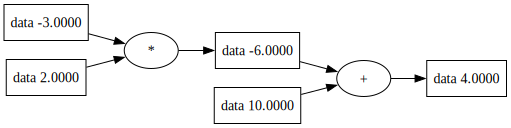

In [24]:
draw_dot(d)

So, let's create a special underscore label or let's just do label equals empty by default and save it in each node.

In [25]:
class Value:

    def __init__(self, data, _children=(), _op='', label=''):
        self.data = data
        self._prev = set(_children)
        self._op = _op
        self.label = label
        
    def __repr__(self):
        return f'Value(data={self.data})'

    def __add__(self, other):
        out = Value(self.data + other.data, (self, other), '+')
        return out
    
    def __mul__(self, other):
        out = Value(self.data * other.data, (self, other), '*')
        return out


In [26]:
a = Value(2.0, label='a')
b = Value(-3.0, label='b')
c = Value(10.0, label='c')
e = a*b; e.label = 'e'
d = e + c; d.label = 'd'
d

Value(data=4.0)

In [27]:
from graphviz import Digraph

def trace(root):
    # builds a set of all nodes and edges in a graph
    nodes, edges = set(), set()
    def build(v):
        if v not in nodes:
            nodes.add(v)
            for child in v._prev:
                edges.add((child, v))
                build(child)
    build(root)
    return nodes, edges

def draw_dot(root):
    dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'}) # LR = left to right

    nodes, edges = trace(root)
    for n in nodes:
        uid = str(id(n))
        # for any value in the graph, create a rectangular ('record') node for it
        dot.node(name = uid, label = '{ %s | data %.4f }' % (n.label, n.data), shape='record')
        if n._op:
            # if this value is a result of some operation, create an op node for it
            dot.node(name = uid + n._op, label = n._op)
            # and connect this node to it
            dot.edge(uid + n._op, uid)
        
    for n1, n2 in edges:
        # connect n1 to the op node of n2
        dot.edge(str(id(n1)), str(id(n2)) + n2._op)
    
    return dot

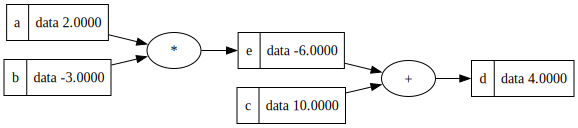

In [28]:
draw_dot(d)

In [29]:
a = Value(2.0, label='a')
b = Value(-3.0, label='b')
c = Value(10.0, label='c')
e = a*b; e.label = 'e'
d = e + c; d.label = 'd'
f = Value(-2.0, label='f')
L = d * f; L.label = 'L'
L

Value(data=-8.0)

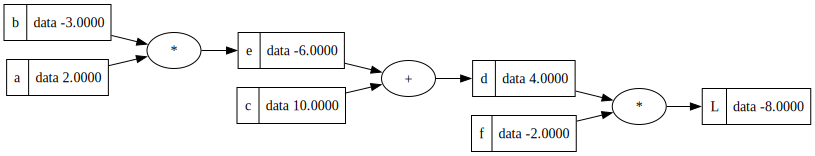

In [30]:
draw_dot(L)

So, let's recap what we've down so far.

We're able to build out mathematical expressions using only plus and times so far. They are scale value along the way. And we can do this forward pass and build out a mathematical expression.

And here is visualizing the forward pass.

Now, what we like to do next is to run back propagation.

In back propagation, we're going to start here at the end, and we're going to reverse and calculate the gradient along all these intermediate values.

What we're computing for every single value here, we're going to compute the derivative of that node with respect to L.

We are going to derive what is the derivative of L with respect to f, with respect to d, with respect to c, with respect to e, with respect to b, and with respect to a.

In neural network setting, you'd be very interested in the derivative of this loss function, L, respect to the weights of a neural network. And we need to know how those weights are impacting the loss function. We will be interested in the derivative of the output with respect to some of its leaf nodes and those leaf nodes will be the weights of the neural net, and the other leaf nodes will be the data itself but usually we will not want or use the derivative of the loss function with respect to data because the data is fixed, but the weights will be iterated on using the gradient information.

So next we are going to create a variable inside the value class that maintains the derivative of L respect to with respect to that value, and we will call this variable grad.

So there's a dot data and there's a self.grad and initially it will be zero.

And remember that zero is basically means no effect.

So at initialization, we're assuming that every value does not impact the output, because if the gradient is zero, that means that changing this variable is not changing the loss function.

In [31]:
class Value:

    def __init__(self, data, _children=(), _op='', label=''):
        self.data = data
        # So by default, we assume that the gradient is zero
        self.grad = 0.0
        self._prev = set(_children)
        self._op = _op
        self.label = label
        
    def __repr__(self):
        return f'Value(data={self.data})'

    def __add__(self, other):
        out = Value(self.data + other.data, (self, other), '+')
        return out
    
    def __mul__(self, other):
        out = Value(self.data * other.data, (self, other), '*')
        return out

In [32]:
a = Value(2.0, label='a')
b = Value(-3.0, label='b')
c = Value(10.0, label='c')
e = a*b; e.label = 'e'
d = e + c; d.label = 'd'
f = Value(-2.0, label='f')
L = d * f; L.label = 'L'
L

Value(data=-8.0)

So we're going to visualize it after data.

In [33]:
from graphviz import Digraph

def trace(root):
    # builds a set of all nodes and edges in a graph
    nodes, edges = set(), set()
    def build(v):
        if v not in nodes:
            nodes.add(v)
            for child in v._prev:
                edges.add((child, v))
                build(child)
    build(root)
    return nodes, edges

def draw_dot(root):
    dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'}) # LR = left to right

    nodes, edges = trace(root)
    for n in nodes:
        uid = str(id(n))
        # for any value in the graph, create a rectangular ('record') node for it
        dot.node(name = uid, label = '{ %s | data %.4f | grad %.4f }' % (n.label, n.data, n.grad), shape='record')
        if n._op:
            # if this value is a result of some operation, create an op node for it
            dot.node(name = uid + n._op, label = n._op)
            # and connect this node to it
            dot.edge(uid + n._op, uid)
        
    for n1, n2 in edges:
        # connect n1 to the op node of n2
        dot.edge(str(id(n1)), str(id(n2)) + n2._op)
    
    return dot

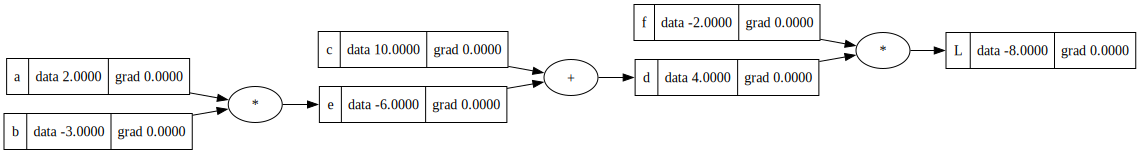

In [34]:
draw_dot(L)

And we are just about getting ready to calculate the back propagation.

grad, is representing the derivative of the output, in this case L, with respect to this value.

So let's now fill in those gradients and actually do back propagation manually.

So what is the derivative of L with respect to L? In other words, if I change L by a tiny amount h, how much does L change?

In [35]:
class Value:

    def __init__(self, data, _children=(), _op='', label=''):
        self.data = data
        # So by default, we assume that the gradient is zero
        self.grad = 0.0
        self._prev = set(_children)
        self._op = _op
        self.label = label
        
    def __repr__(self):
        return f'Value(data={self.data})'

    def __add__(self, other):
        out = Value(self.data + other.data, (self, other), '+')
        return out
    
    def __mul__(self, other):
        out = Value(self.data * other.data, (self, other), '*')
        return out

In [36]:
a = Value(2.0, label='a')
b = Value(-3.0, label='b')
c = Value(10.0, label='c')
e = a*b; e.label = 'e'
d = e + c; d.label = 'd'
f = Value(-2.0, label='f')
L = d * f; L.label = 'L'
L

Value(data=-8.0)

we have L = d * f, we want to know what is dL/dd = ? f

we go back to the definition of derivative, 
(f(x+h) - f(x)) / h, 
((d + h) * f - d * f) / h,
h * f / h,
f

and dL/df = d

In [37]:
def lol():

    h = 0.0001

    a = Value(2.0, label='a')
    b = Value(-3.0, label='b')
    c = Value(10.0, label='c')
    e = a*b; e.label = 'e'
    d = e + c; d.label = 'd'
    f = Value(-2.0, label='f')
    L = d * f; L.label = 'L'
    L1 = L.data

    a = Value(2.0 , label='a')
    b = Value(-3.0, label='b')
    c = Value(10.0, label='c')
    e = a*b; e.label = 'e'
    d = e + c; d.label = 'd'
    f = Value(-2.0, label='f')
    L = (d * f); L.label = 'L'
    L2 = L.data + h

    print((L2 - L1)/h)
lol()
# L.grad = 1.0

0.9999999999976694


In [38]:
def lol():

    h = 0.0001

    a = Value(2.0, label='a')
    b = Value(-3.0, label='b')
    c = Value(10.0, label='c')
    e = a*b; e.label = 'e'
    d = e + c; d.label = 'd'
    f = Value(-2.0, label='f')
    L = d * f; L.label = 'L'
    L1 = L.data

    a = Value(2.0 + h, label='a')
    b = Value(-3.0, label='b')
    c = Value(10.0, label='c')
    e = a*b; e.label = 'e'
    d = e + c; d.label = 'd'
    f = Value(-2.0, label='f')
    L = (d * f); L.label = 'L'
    L2 = L.data

    print((L2 - L1)/h)
lol()
# a.grad = 6.0

6.000000000021544


In [39]:
def lol():

    h = 0.0001

    a = Value(2.0, label='a')
    b = Value(-3.0, label='b')
    c = Value(10.0, label='c')
    e = a*b; e.label = 'e'
    d = e + c; d.label = 'd'
    f = Value(-2.0, label='f')
    L = d * f; L.label = 'L'
    L1 = L.data

    a = Value(2.0, label='a')
    b = Value(-3.0 + h, label='b')
    c = Value(10.0, label='c')
    e = a*b; e.label = 'e'
    d = e + c; d.label = 'd'
    f = Value(-2.0, label='f')
    L = (d * f); L.label = 'L'
    L2 = L.data

    print((L2 - L1)/h)
lol()
# b.grad = -4.0

-4.000000000008441


In [40]:
def lol():

    h = 0.0001

    a = Value(2.0, label='a')
    b = Value(-3.0, label='b')
    c = Value(10.0, label='c')
    e = a*b; e.label = 'e'
    d = e + c; d.label = 'd'
    f = Value(-2.0, label='f')
    L = d * f; L.label = 'L'
    L1 = L.data

    a = Value(2.0, label='a')
    b = Value(-3.0, label='b')
    c = Value(10.0 + h, label='c')
    e = a*b; e.label = 'e'
    d = e + c; d.label = 'd'
    f = Value(-2.0, label='f')
    L = (d * f); L.label = 'L'
    L2 = L.data

    print((L2 - L1)/h)
lol()
# c.grad = -2.0

-1.9999999999953388


In [41]:
def lol():

    h = 0.0001

    a = Value(2.0, label='a')
    b = Value(-3.0, label='b')
    c = Value(10.0, label='c')
    e = a*b; e.label = 'e'
    d = e + c; d.label = 'd'
    f = Value(-2.0, label='f')
    L = d * f; L.label = 'L'
    L1 = L.data

    a = Value(2.0, label='a')
    b = Value(-3.0, label='b')
    c = Value(10.0, label='c')
    e = a*b; e.label = 'e'
    e.data += h
    d = e + c; d.label = 'd'
    f = Value(-2.0, label='f')
    L = (d * f); L.label = 'L'
    L2 = L.data

    print((L2 - L1)/h)
lol()
# e.grad = -2.0

-1.9999999999953388


In [42]:
def lol():

    h = 0.0001

    a = Value(2.0, label='a')
    b = Value(-3.0, label='b')
    c = Value(10.0, label='c')
    e = a*b; e.label = 'e'
    d = e + c; d.label = 'd'
    f = Value(-2.0, label='f')
    L = d * f; L.label = 'L'
    L1 = L.data

    a = Value(2.0, label='a')
    b = Value(-3.0, label='b')
    c = Value(10.0, label='c')
    e = a*b; e.label = 'e'
    d = e + c; d.label = 'd'
    d.data += h
    f = Value(-2.0, label='f')
    L = (d * f); L.label = 'L'
    L2 = L.data

    print((L2 - L1)/h)
lol()
# d.grad = -2.0

-1.9999999999953388


In [43]:
def lol():

    h = 0.0001

    a = Value(2.0, label='a')
    b = Value(-3.0, label='b')
    c = Value(10.0, label='c')
    e = a*b; e.label = 'e'
    d = e + c; d.label = 'd'
    f = Value(-2.0, label='f')
    L = d * f; L.label = 'L'
    L1 = L.data

    a = Value(2.0 , label='a')
    b = Value(-3.0, label='b')
    c = Value(10.0, label='c')
    e = a*b; e.label = 'e'
    d = e + c; d.label = 'd'
    f = Value(-2.0 + h, label='f')
    L = (d * f); L.label = 'L'
    L2 = L.data

    print((L2 - L1)/h)
lol()
# f.grad = 4.0

3.9999999999995595


In [44]:
L.grad = 1.0
d.grad = -2.0
f.grad = 4.0
e.grad = -2.0
c.grad = -2.0
a.grad = 6.0
b.grad = -4.0

In [45]:
from graphviz import Digraph

def trace(root):
    # builds a set of all nodes and edges in a graph
    nodes, edges = set(), set()
    def build(v):
        if v not in nodes:
            nodes.add(v)
            for child in v._prev:
                edges.add((child, v))
                build(child)
    build(root)
    return nodes, edges

def draw_dot(root):
    dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'}) # LR = left to right

    nodes, edges = trace(root)
    for n in nodes:
        uid = str(id(n))
        # for any value in the graph, create a rectangular ('record') node for it
        dot.node(name = uid, label = '{ %s | data %.4f | grad %.4f }' % (n.label, n.data, n.grad), shape='record')
        if n._op:
            # if this value is a result of some operation, create an op node for it
            dot.node(name = uid + n._op, label = n._op)
            # and connect this node to it
            dot.edge(uid + n._op, uid)
        
    for n1, n2 in edges:
        # connect n1 to the op node of n2
        dot.edge(str(id(n1)), str(id(n2)) + n2._op)
    
    return dot

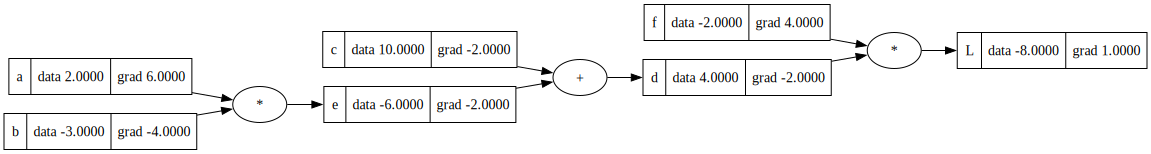

In [46]:
draw_dot(L)

We have the final output value all the way at the end of this graph. And we're now like a small node here. And this is a little plus node. 

L = d * f
d = e + c
e = a * b

local derivative

dL / dd = f = -2
dL / df = d = 4

---------------------------
This is a little plus node, and the little plus node doesn't know anything about the rest of the graph that it's embedded in. All it knows is that it did a plus. It took a 'c' and 'e', added them, and create 'd', and this plus node also knows the local influence of 'c' on 'd' or rather the derivative of 'd' with the respect to 'c', and it also knows the derivative of 'd' with respect to 'e', that's just a local derivative. What we want is 'dL/dc'. 

We know how 'd' impacts 'L' and how 'c' and 'e' impacts 'd'. And how do we put that information together to write dL/dc?
The chain rule in calculus. 
And the chain rule states that knowing the instantaneous rate of change of Z with respect to Y, and Y relative to X allows one to calculate the instantaneous rate of change of Z relative to X, as a product of those two rates of change. Simply the product of those two.

So literally what a plus node does, you can look at it that way, is it literally just routes the gradient because the plus nodes local derivative are just one. So in the chain rule, one times dL/dd is just dL/dd. And so that derivative just gets routed to both 'c' and 'e' in this case. 

dd / de = 1
dd / dc = 1
----------------------------

de / da = b = -3
de / db = a = 2

L.grad = dL / dL = 1
d.grad = dL / dd = f = -2
f.grad = dL / df = d = 4
e.grad = dL / de = (dL / dd) * (dd / de) = dL / dd = -2 * 1 = -2
c.grad = dL / dc = (dL / dd) * (dd / dc) = dL / dd = -2 * 1 = -2
a.grad = dL / da = (dL / dd) * (dd / de) * (de / da) = -2 * b = -2 * (-3) = 6
b.grad = dL / db = (dL / dd) * (dd / de) * (de / db) = -2 * a = -2 * 2 = -4

So this back-propagating single, which is carrying the information of like, what is the derivative of L with respect to all the intermediate node? 

We can imagine it almost like flowing backwards through the graph and a plus node will simply distribute the derivative to all the children nodes of it.

We've done is as you saw iterated through all the nodes one by one and locally applied the chain rule, we always know what is the derivative of L with respect to this little output and then we look at how this output was produced, this output was produced through some operation and we have the pointers to the children nodes of this through some operation and we have the pointers to the children nodes of this operation. And so in this little operation, we know what the local derivatives are and we just multiply them onto the derivative always. So we just go through and recursively multiply on the local derivatives. And that's what back propagation is.

Let's see this power in action just very briefly.

We're going to nudge our inputs to try to make L go up.

And we want L to go up, that means we just have to go in the direction of the gradient.

In [47]:
# So should increase in the direction of gradient by like some small step amount.
a.data += 0.01 * a.grad
b.data += 0.01 * b.grad
c.data += 0.01 * c.grad
f.data += 0.01 * f.grad

e = a * b
d = e + c
L = d * f

print(L.data)

-7.286496


So now I would like to do one more example of manual back propagation using a bit more complex and useful example.

We are going to back propagate through a neuron.

We want to eventually build up neural networks. And in the simplest case, these are multilayer perceptron. So this is a two-layer neural net.

we have some inputs 'xs', and then we have these synapses that have weights on them, so the 'ws' are weights, and then the synapse interacts with the input to this neuron multiplicatively, so what flows to the cell body of this neuron is 'w times x', but there's multiple inputs. 
So there's many 'ws times xs' flowing into the cell body. And the cell body then has also like bias. So the bias can make it a bit more trigger happy or a bit less trigger happy, regardless of the input. 
But basically we're taking all the w times x of all the inputs, adding this bias, and then we take it through an activation function. And this activation function is usually some kind of a squashing function, like a sigmoid or tanh or something like that.

So as an example, we're going to use the tanh in this example.

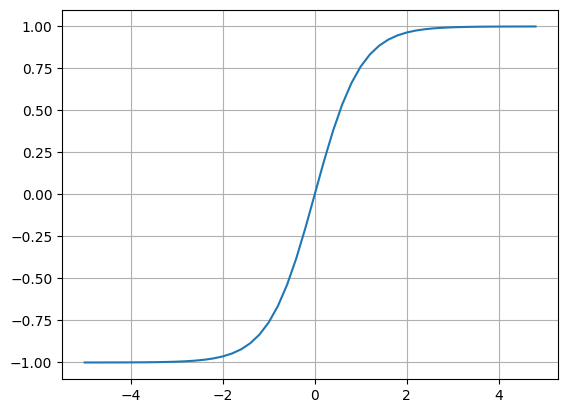

In [48]:
plt.plot(np.arange(-5,5,0.2), np.tanh(np.arange(-5,5,0.2))); plt.grid()

And you see that the inputs as they come in get squashed on the white coordinate here, so right at zero, we're going to get exactly zero and then as you go more positive in the input then you will see that the function will only go up to one and then plateau out. And so if you pass in very positive inputs, we're going to cap it smoothly at one. And at the negative side, we are going to cap it smoothly at negative one.

And what comes out of this neuron is just the activation function applied to the dot product of the weights and the inputs.

In [49]:
class Value:

    def __init__(self, data, _children=(), _op='', label=''):
        self.data = data
        self.grad = 0.0
        self._prev = set(_children)
        self._op = _op
        self.label = label

    def __repr__(self):
        return f'Value(data={self.data})'
    # what the repr is doing is it's providing us a way to point out like a nice looking expression in Python

    def __add__(self, other):
        out = Value(self.data + other.data, (self, other), '+')
        return out
    
    def __mul__(self, other):
        out = Value(self.data * other.data, (self, other), '*')
        return out

In [50]:
from graphviz import Digraph

def trace(root):
    # builds a set of all nodes and edges in a graph
    nodes, edges = set(), set()
    def build(v):
        if v not in nodes:
            nodes.add(v)
            for child in v._prev:
                edges.add((child, v))
                build(child)
    build(root)
    return nodes, edges

def draw_dot(root):
    dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'}) # LR = left to right

    nodes, edges = trace(root)
    for n in nodes:
        uid = str(id(n))
        # for any value in the graph, create a rectangular ('record') node for it
        dot.node(name = uid, label = '{ %s | data %.4f | grad %.4f }' % (n.label, n.data, n.grad), shape='record')
        if n._op:
            # if this value is a result of some operation, create an op node for it
            dot.node(name = uid + n._op, label = n._op)
            # and connect this node to it
            dot.edge(uid + n._op, uid)
        
    for n1, n2 in edges:
        # connect n1 to the op node of n2
        dot.edge(str(id(n1)), str(id(n2)) + n2._op)
    
    return dot

In [51]:
# inputs x1, x2
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')

# weights w1, w2
# these weights, are the synaptic strengths for each inputs.
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')

# bias of the neuron
b = Value(6.7, label='b')

# x1*w1 + x2*w2 + b
x1w1 = x1*w1; x1w1.label = 'x1*w1'
x2w2 = x2*w2; x2w2.label = 'x2*w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1*w1 + x2*w2'
n = x1w1x2w2 + b; n.label = 'n'

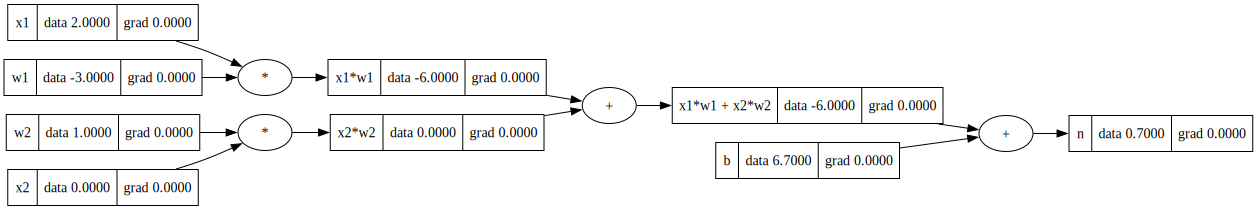

In [52]:
draw_dot(n)

So, we'd like to do here is to do the output, and call it 'o', is 'o.tanh()', but we haven't yet written the tanh.

Now, the reason that we need to implement another tanh function here is that tanh is a hyperbolic function, and we've only so far implemented a 'plus' and a 'times', and you can't make tanh out just 'plus' and 'times'. You also need exponentiation.

tanh(x) = sinh(x) / cosh(x) = (e^x - e^-x) / (e^x + e^-x) = (e^2x - 1) / (e^2x + 1)

And you see that there is exponentiation involved, which we have not implemented yet for our little value node here. So we're not going to be able to produce tanh yet, and we have to go back up and implement something like it.

And one option here is we could actually implement exponentiation and we could return the 'exp' of value instead of a 'tanh' of a value, because if we have 'exp' then we have everything else that we need, we know to 'add' and we know how to 'multiply'. So we'd able to create 'tanh' if we knew how to 'exp'.

But for the purposes of this example, I specifically wanted to show you that we don't necessarily need to have the most atomic pieces in this value object. We can actually create functions at arbitrary points of abstraction, they can be complicated functions but they can be also very simple functions like a plus and it's totally up to us the only thing that matters is that we know how to differentiate through any one function because we take some inputs and we make an output, the only thing that matters it can be arbitrarily complex function as long as you know how to create the local derivative, if you know the local derivative of how the inputs impacts the output then that's all you need.

So, we're going to cluster up all of this expression and we're not going to break it down to its atomic pieces. We're just going to directly implement tanh.

In [53]:
class Value:

    def __init__(self, data, _children=(), _op='', label=''):
        self.data = data
        self.grad = 0.0
        self._prev = set(_children)
        self._op = _op
        self.label = label

    def __repr__(self):
        return f'Value(data={self.data})'
    # what the repr is doing is it's providing us a way to point out like a nice looking expression in Python

    def __add__(self, other):
        out = Value(self.data + other.data, (self, other), '+')
        return out
    
    def __mul__(self, other):
        out = Value(self.data * other.data, (self, other), '*')
        return out

    def tanh(self):
        x = self.data
        t = (math.exp(2*x) - 1)/(math.exp(2*x) + 1)
        out = Value(t, (self, ), 'tanh')
        return out

As long as we know the derivative of tanh, then we'll be able to back propagate through it.

In [56]:
# inputs x1, x2
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')

# weights w1, w2
# these weights, are the synaptic strengths for each inputs.
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')

# bias of the neuron
b = Value(6.7, label='b')

# x1*w1 + x2*w2 + b
x1w1 = x1*w1; x1w1.label = 'x1*w1'
x2w2 = x2*w2; x2w2.label = 'x2*w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1*w1 + x2*w2'
n = x1w1x2w2 + b; n.label = 'n'
o = n.tanh(); o.label = 'o'

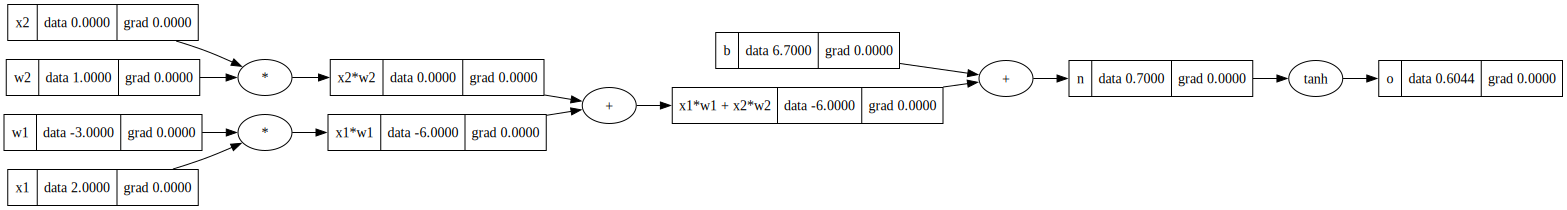

In [57]:
draw_dot(o)

Let's see this tanh in action.

Currently it's not squashing too much because the input to it is pretty low. So the bias was increased to, say, 8, then we'll see that what's flowing into the tanh now is 2 and tanh squashing it to 0.964, so we already hitting the tail of this tanh.

In [58]:
# inputs x1, x2
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')

# weights w1, w2
# these weights, are the synaptic strengths for each inputs.
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')

# bias of the neuron
b = Value(8.0, label='b')

# x1*w1 + x2*w2 + b
x1w1 = x1*w1; x1w1.label = 'x1*w1'
x2w2 = x2*w2; x2w2.label = 'x2*w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1*w1 + x2*w2'
n = x1w1x2w2 + b; n.label = 'n'
o = n.tanh(); o.label = 'o'

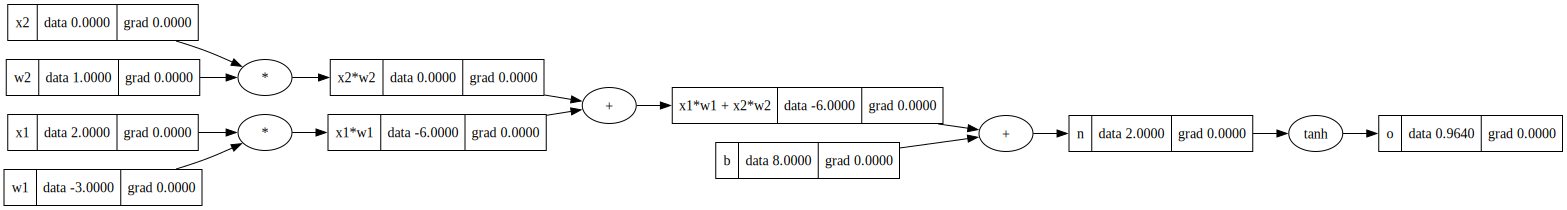

In [59]:
draw_dot(o)

So, I'm going to do something slightly strange. I'm going to change this bias to this number, 6.8813735870195432

And I'm going to do this for specific reasons because we're about to start bac propagation. And I want to make sure that our numbers come out nice. They're not like very crazy numbers. They're nice numbers that we can sort of understand in our hand.

In [68]:
# inputs x1, x2
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')

# weights w1, w2
# these weights, are the synaptic strengths for each inputs.
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')

# bias of the neuron
b = Value(6.8813735870195432, label='b')

# x1*w1 + x2*w2 + b
x1w1 = x1*w1; x1w1.label = 'x1*w1'
x2w2 = x2*w2; x2w2.label = 'x2*w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1*w1 + x2*w2'
n = x1w1x2w2 + b; n.label = 'n'
o = n.tanh(); o.label = 'o'

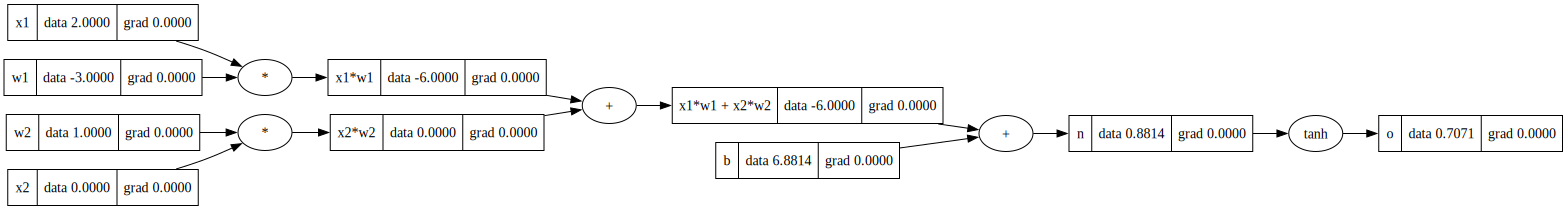

In [69]:
draw_dot(o)

So now we're going to do back propagation, and we're going to fill in all the gradient.

So what is the derivative of 'o' with respect to all the inputs here? 

And in the neural network setting, what we really care about the most is the derivative of these neurons on the weights specifically, the 'w2' and 'w1', because those are the weights that we're going to be changing in part of the optimization.

And the other thing that we have to remember is here we have only a single neuron, but in the neural net you typically have many neurons and they're connected.

So this is only like one small neuron, a piece of a much bigger puzzle, and eventually there's a loss function that sort of measures the accuracy of the neural net, and we're back propagating with respect to that accuracy and trying to increase it. 

In [81]:
o.grad = 1.0
n.grad = 0.5
x1w1x2w2.grad = 0.5
b.grad = 0.5
x1w1.grad = 0.5
x2w2.grad = 0.5
x1.grad = -1.5
w1.grad = 1.0
x2.grad = 0.5
w2.grad = 0.0

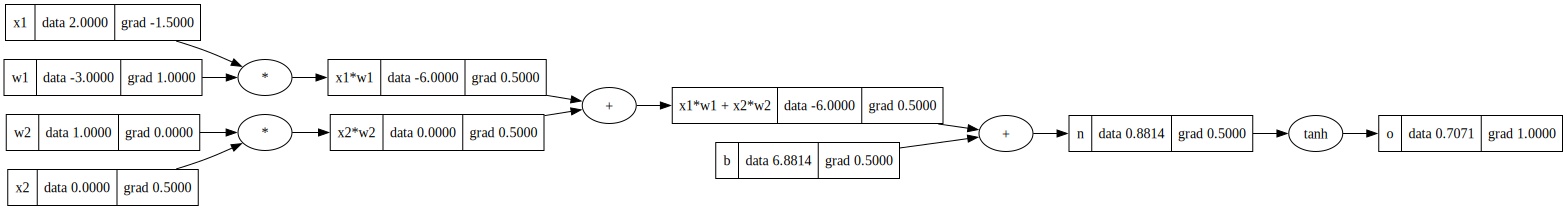

In [82]:
draw_dot(o)

So we're going to back propagate through the tanh so to back propagate through tanh, we need to know the local derivative of tanh, so if we have that'o' is 'tanh of n' then what 'do / dn'?

do / dn = ?

dtanh(x) / dx = 1 - tanh(x)^2 = sech(x)^2 = 1 / cosh(x)^2

o = tanh(n)

do / dn = 1 - tanh(n)^2 = 1 - o^2

In [73]:
o.data

0.7071067811865476

In [ ]:
1 - o.data**2
# n.grad

0.4999999999999999

So now we're going to continue the back propagation

A plus is just a distributor of gradient, so this gradient will simply flow to both of these equally. And that because the local derivative of this operation is one of every one of its nodes.

dn / d(x1 * w1 + x2 * w2) = 1.0
dn / db = 1.0

x1w1x2w2.grad = 0.5
b.grad = 0.5

x1w1.grad = 0.5
x2w2.grad = 0.5

Keep in mind again, what the derivative is telling us at every point in time along here. This is saying that if we want the output of this neuron to increase then the influence on these expressions is positive on the output. Both of them are positive contribution to the output. 

x1.grad = w1.data * x1w1.grad = (-3) * 0.5 = -1.5
w1.grad = x1.data * x1w1.grad = 2 * 0.5 = 1.0

x2.grad = w2.data * x2w2.grad = 1.0 * 0.5 = 0.5
w2.grad = x2.data * x2w2.grad = 0.0 * 0.5 = 0.0

Derivative always tells us the influence of this on the final output, if I wiggle w2, how is the output changing?
It's not changing, because we're multiplying by zero.

So, if we want this neurons output to increase, we know that what's necessary is that 'w2', we have no gradient, doesn't actually matter to this neuron right now. But this neuron, 'w1', should go up, this weight goes up, then this neuron's output would have gone up proportionally, because the gradient is one.

Doing back propagation manually is obviously ridiculous. So we're now going to put an end to this suffering and we're going to see how we can implement the back propagation, the backward pass a bit more automatically. We're not going to be doing all of it manually out here. It's now pretty obvious to us by example how these plus and times are back propagation gradients.

So let's go up to the value object and we're going to start co-defying what we've seen in the examples below.

So, we're going to do this by storing a special self.backward, and underscore backward, and this will be a function which is going to do that little piece of chain rule at each little node that took inputs and produced output. We're going to store how we are going to chain to outputs gradient into the inputs gradients. 

So by default, this will be a function that doesn't do anything. And that would be sort of the case, for a leaf node, there's nothing to do. 

But when we creating these 'out' value, these 'out' values are an addition of self and other. And so we will want to set 'out's backward to be the function that propagates the gradient. And we're going to store it in a closure. 

Let's define what should happen when we call 'out's' grad.

We want the local derivative times the sort of global derivative which is the derivative of the final output of the expression with respect to out's data with the respect to out.

So the local derivative of self in an addition is 1.0

In [108]:
class Value:

    def __init__(self, data, _children=(), _op='', label=''):
        self.data = data
        self.grad = 0.0
        self._backward = lambda: None
        self._prev = set(_children)
        self._op = _op
        self.label = label

    def __repr__(self):
        return f'Value(data={self.data})'
    # what the repr is doing is it's providing us a way to point out like a nice looking expression in Python

    def __add__(self, other):
        out = Value(self.data + other.data, (self, other), '+')

        def _backward():
            self.grad = 1.0 * out.grad
            other.grad = 1.0 * out.grad
        
        out._backward = _backward

        return out
    
    def __mul__(self, other):
        out = Value(self.data * other.data, (self, other), '*')

        def _backward():
            self.grad = other.data * out.grad
            other.grad = self.data * out.grad

        out._backward = _backward

        return out

    def tanh(self):
        x = self.data
        t = (math.exp(2*x) - 1)/(math.exp(2*x) + 1)
        out = Value(t, (self, ), 'tanh')

        def _backward():
            self.grad = (1 - t**2) * out.grad
        
        out._backward = _backward

        return out

And so we're going to redefine the expression, make sure that all the grads are zero, but now we don't have to do this manually anymore.

In [109]:
# inputs x1, x2
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')

# weights w1, w2
# these weights, are the synaptic strengths for each inputs.
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')

# bias of the neuron
b = Value(6.8813735870195432, label='b')

# x1*w1 + x2*w2 + b
x1w1 = x1*w1; x1w1.label = 'x1*w1'
x2w2 = x2*w2; x2w2.label = 'x2*w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1*w1 + x2*w2'
n = x1w1x2w2 + b; n.label = 'n'
o = n.tanh(); o.label = 'o'

out.grad is initialized to 0.0, so as the base case, we need to set both that grad to 1.0, to initialize to 1.0

In [92]:
o.grad = 1.0
o._backward()
n._backward()
x1w1x2w2._backward()
x1w1._backward()
x2w2._backward()

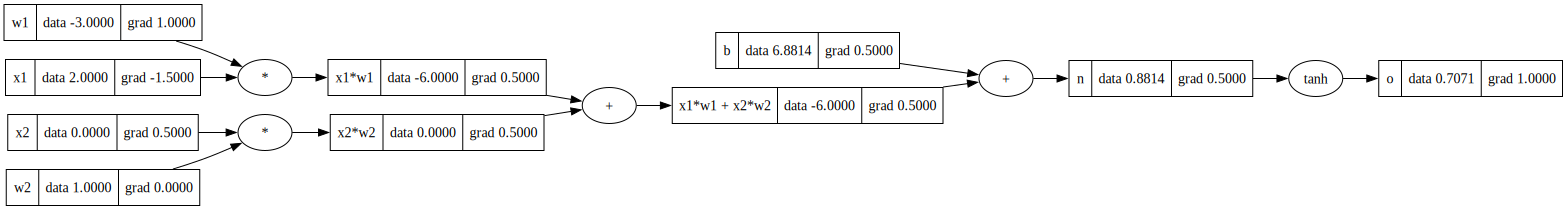

In [93]:
draw_dot(o)

So we've laid out a mathematical expression and now we're trying to go backwards through that expression, so going backwards through the expression just means that we never want to call a dot backward for any node before we've done sort of everything after it.

So we have to do everything after it before we're ever going to call .backward on any one node. We have to get all of its full dependencies, everything that it depends on has to propagate to it before we can continue back propagation. 

So the ordering of graphs can be achieved using something called topological sort.

In [ ]:
# inputs x1, x2
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')

# weights w1, w2
# these weights, are the synaptic strengths for each inputs.
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')

# bias of the neuron
b = Value(6.8813735870195432, label='b')

# x1*w1 + x2*w2 + b
x1w1 = x1*w1; x1w1.label = 'x1*w1'
x2w2 = x2*w2; x2w2.label = 'x2*w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1*w1 + x2*w2'
n = x1w1x2w2 + b; n.label = 'n'
o = n.tanh(); o.label = 'o'

In [105]:
topo = []
visited = set()
def build_topo(v):
    if v not in v._prev:
        visited.add(v)
        for child in v._prev:
            build_topo(child)
        topo.append(v)
build_topo(o)
topo

[Value(data=1.0),
 Value(data=0.0),
 Value(data=0.0),
 Value(data=-3.0),
 Value(data=2.0),
 Value(data=-6.0),
 Value(data=-6.0),
 Value(data=6.881373587019543),
 Value(data=0.8813735870195432),
 Value(data=0.7071067811865476)]

This is basically what builds a topological graph. We maintain a set of visited nodes, and then we are going through, starting at some root node, which for us is 'o'. That's where we want to start the topological sort.

And starting at 'o', we are go through all of its children, and we need to lay them out from left to right.

And really what we're doing now is we're just calling dot underscore backward on all of the node in a topological order.

In [111]:
o.grad = 1.0

topo = []
visited = set()
def build_topo(v):
    if v not in v._prev:
        visited.add(v)
        for child in v._prev:
            build_topo(child)
        topo.append(v)
build_topo(o)
topo

for node in reversed(topo):
    node._backward()

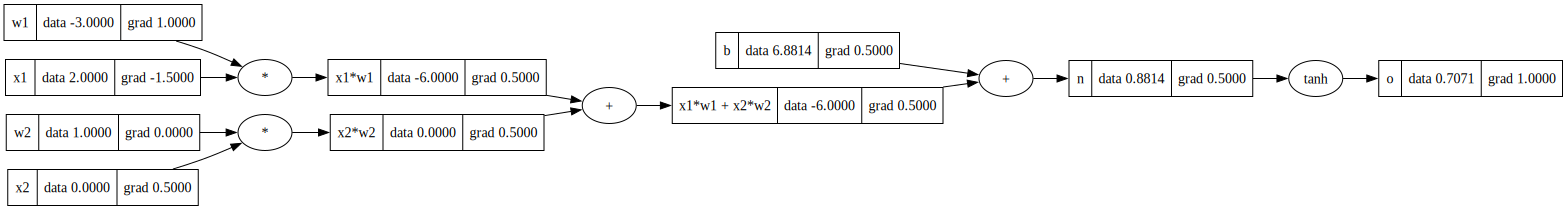

In [112]:
draw_dot(o)

In [117]:
class Value:

    def __init__(self, data, _children=(), _op='', label=''):
        self.data = data
        self.grad = 0.0
        self._backward = lambda: None
        self._prev = set(_children)
        self._op = _op
        self.label = label

    def __repr__(self):
        return f'Value(data={self.data})'
    # what the repr is doing is it's providing us a way to point out like a nice looking expression in Python

    def __add__(self, other):
        out = Value(self.data + other.data, (self, other), '+')

        def _backward():
            self.grad = 1.0 * out.grad
            other.grad = 1.0 * out.grad
        
        out._backward = _backward

        return out
    
    def __mul__(self, other):
        out = Value(self.data * other.data, (self, other), '*')

        def _backward():
            self.grad = other.data * out.grad
            other.grad = self.data * out.grad

        out._backward = _backward

        return out

    def tanh(self):
        x = self.data
        t = (math.exp(2*x) - 1)/(math.exp(2*x) + 1)
        out = Value(t, (self, ), 'tanh')

        def _backward():
            self.grad = (1 - t**2) * out.grad
        
        out._backward = _backward

        return out

    def backward(self):
        
        topo = []
        visited = set()
        def build_topo(v):
            if v not in v._prev:
                visited.add(v)
                for child in v._prev:
                    build_topo(child)
                topo.append(v)
        build_topo(self)
        topo

        self.grad = 1.0
        for node in reversed(topo):
            node._backward()

In [118]:
# inputs x1, x2
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')

# weights w1, w2
# these weights, are the synaptic strengths for each inputs.
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')

# bias of the neuron
b = Value(6.8813735870195432, label='b')

# x1*w1 + x2*w2 + b
x1w1 = x1*w1; x1w1.label = 'x1*w1'
x2w2 = x2*w2; x2w2.label = 'x2*w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1*w1 + x2*w2'
n = x1w1x2w2 + b; n.label = 'n'
o = n.tanh(); o.label = 'o'

In [121]:
o.backward()

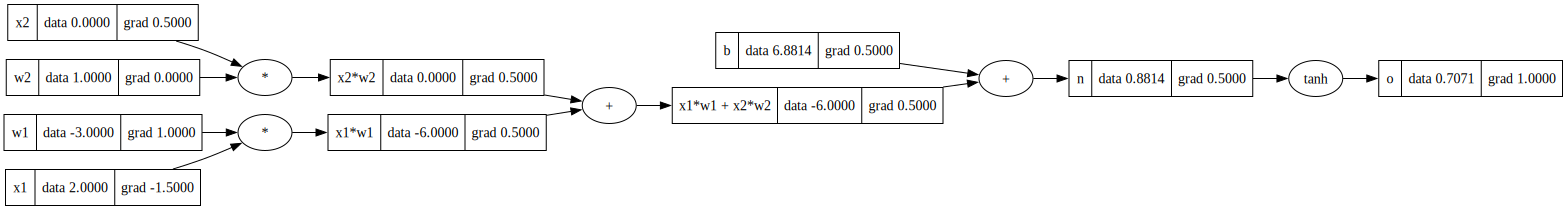

In [122]:
draw_dot(o)

We shouldn't be too happy with ourselves actually because we have a bad bug and we have not surfaced the bug because of some specific conditions that we have to think about right now.

Here the list to show the bug.

In [ ]:
a.Value(3.0, label='a')
b = a + a; b.label = 'b'
b.backward()
draw_dot(b)

So what's going to happen is 'a' is 3, and then 'b' is 'a' plus 'a'. So there's two arrows on top of each other here. 

Then we can see that 'b', the forward pass works, is 6. But the gradient here is not actually correct, that we calculated automatically. 

And that's because 'b' is the result of the addition, then when we called backward what happened is self.grad was set to 1 and other.grad was set to 1, because we're doing 'a' plus 'a' self and other are actually the exact same object so we are overriding the gradient, we are setting it to 1 and then we are setting it again to 1, and that's why it says at 1, so that's a problem.

There's another way to see this in a little bit more complicated expression.

we call f.backward and these gradients if you check will be incorrect so fundamentally what's happening here again is we're going to see an issue anytime we use a variable more then once. 

In [ ]:
a = Value(-2.0, label='a')
b = Value(3.0, label='b')
d = a * b; d.label = 'd'
e = a + b; e.label = 'e'
f = d * e; f.label = 'f'

f.backward()

draw_dot(f)

The expression above, every variable is used exactly once, so we didn't see the issue.

But here, if the variable is used more than once, what's going to happen during backward pass?
We are back-propagating from 'f' to 'e' to 'd', so far so good, but now 'e' calls it backward, and it deposits its gradients to 'a' and 'b', but then we come back to 'd' and call backward, and it overwrites those gradient at 'a' and 'b'. So that's obviously a problem.

And the solution here, if you look at the multivariate case of the chain rule and the solution there is basically that we have to accumulate these gradient. And so instead of setting those gradients, we can simply do plus equals. We need to accumulate those gradients.

In [ ]:
class Value:

    def __init__(self, data, _children=(), _op='', label=''):
        self.data = data
        self.grad = 0.0
        self._backward = lambda: None
        self._prev = set(_children)
        self._op = _op
        self.label = label

    def __repr__(self):
        return f'Value(data={self.data})'
    # what the repr is doing is it's providing us a way to point out like a nice looking expression in Python

    def __add__(self, other):
        out = Value(self.data + other.data, (self, other), '+')

        def _backward():
            self.grad += 1.0 * out.grad
            other.grad += 1.0 * out.grad
        
        out._backward = _backward

        return out
    
    def __mul__(self, other):
        out = Value(self.data * other.data, (self, other), '*')

        def _backward():
            self.grad += other.data * out.grad
            other.grad += self.data * out.grad

        out._backward = _backward

        return out

    def tanh(self):
        x = self.data
        t = (math.exp(2*x) - 1)/(math.exp(2*x) + 1)
        out = Value(t, (self, ), 'tanh')

        def _backward():
            self.grad += (1 - t**2) * out.grad
        
        out._backward = _backward

        return out

    def backward(self):
        
        topo = []
        visited = set()
        def build_topo(v):
            if v not in v._prev:
                visited.add(v)
                for child in v._prev:
                    build_topo(child)
                topo.append(v)
        build_topo(self)
        topo

        self.grad = 1.0
        for node in reversed(topo):
            node._backward()

Remember because we are initializing them at zero, so they start at zero and then any contribution that flows backward will simply add.

Because a.grad started at zero, and when we call b.backward, we deposit one, and then we deposit one again, and now this is two, which is correct.

In [ ]:
a.Value(3.0, label='a')
b = a + a; b.label = 'b'
b.backward()
draw_dot(b)

This will also work, and we'll get correct gradients, because when call e.backward, we will deposit the gradients for the branch, and then when we get to d.backward, it will deposit its own gradients, and then those gradients simply add on top of each other. And so we just accumulate those gradients, and that fixes the issue.

In [ ]:
a = Value(-2.0, label='a')
b = Value(3.0, label='b')
d = a * b; d.label = 'd'
e = a + b; e.label = 'e'
f = d * e; f.label = 'f'

f.backward()

draw_dot(f)

Let's come back to this non-linearity here that we implemented the 'tanh'.

Now I told you that we could have broken down 'tanh' into its explicit atoms in terms of other expressions if we had the 'exp' function. So if you remember 'tanh' is defined like this 'tanh(x) = sinh(x) / cosh(x) = (e^x - e^-x) / (e^x + e^-x) = (e^2x - 1) / (e^2x + 1)', and we chose to develop 'tanh' as a single function and we can do that, because we know it's derivative and we can back propagate through it. But we can also break down 'tanh' into and express it as a function of 'exp' and I would like to do that now because I want to prove to you that you get all the same results and all the same gradients but also because it forces us to implement a few more expressions.

Let's scroll up to the definition of value.

In [ ]:
a = Value(2.0)
a + 1

We can't do that because it says int object has no attribute data that's because 'a' plus 1 comes right here to add and then other is the integer 1, and then here python is trying to access 1.data and that's not a thing and that's because basically 1 is not a value object and we only have addition for value object so as a matter of convenience so that we can create expressions like this and make them make sense we can simply do something like this. 

Basically, we let other alone if other is an instance of value. But if it's not an instance of value, we're going to assume that it's a number, like an integer or a float, and we're going to simply wrap it in the value.

In [ ]:
class Value:

    def __init__(self, data, _children=(), _op='', label=''):
        self.data = data
        self.grad = 0.0
        self._backward = lambda: None
        self._prev = set(_children)
        self._op = _op
        self.label = label

    def __repr__(self):
        return f'Value(data={self.data})'
    # what the repr is doing is it's providing us a way to point out like a nice looking expression in Python

    def __add__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data + other.data, (self, other), '+')

        def _backward():
            self.grad += 1.0 * out.grad
            other.grad += 1.0 * out.grad
        
        out._backward = _backward

        return out
    
    def __mul__(self, other):
        out = Value(self.data * other.data, (self, other), '*')

        def _backward():
            self.grad += other.data * out.grad
            other.grad += self.data * out.grad

        out._backward = _backward

        return out

    def tanh(self):
        x = self.data
        t = (math.exp(2*x) - 1)/(math.exp(2*x) + 1)
        out = Value(t, (self, ), 'tanh')

        def _backward():
            self.grad += (1 - t**2) * out.grad
        
        out._backward = _backward

        return out

    def backward(self):
        
        topo = []
        visited = set()
        def build_topo(v):
            if v not in v._prev:
                visited.add(v)
                for child in v._prev:
                    build_topo(child)
                topo.append(v)
        build_topo(self)
        topo

        self.grad = 1.0
        for node in reversed(topo):
            node._backward()